In [1]:
import torch
from logits_processor_zoo.vllm import MultipleChoiceLogitsProcessor
import pandas as pd
from transformers import AutoModelForCausalLM, AutoTokenizer
import os
os.environ["VLLM_USE_V1"] = "0"
import vllm

model_path = "./qwen_model/models--Qwen--Qwen1.5-1.8B/snapshots/7846de7ed421727b318d6605a0bfab659da2c067"

llm = vllm.LLM(
    model_path,
    tensor_parallel_size=torch.cuda.device_count(),
    gpu_memory_utilization=0.95,
    trust_remote_code=True,
    dtype="half",
    enforce_eager=True,
    max_model_len=4096,
    disable_log_stats=True,
    enable_prefix_caching=True
)
tokenizer = llm.get_tokenizer()


2025-07-27 14:29:39.510038: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-27 14:29:39.530969: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-27 14:29:39.530994: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-27 14:29:39.531829: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-27 14:29:39.535825: I tensorflow/core/platform/cpu_feature_guar

INFO 07-27 14:29:40 [__init__.py:235] Automatically detected platform cuda.
WARNING 07-27 14:29:45 [config.py:3443] Casting torch.bfloat16 to torch.float16.
INFO 07-27 14:29:45 [config.py:1604] Using max model len 4096
WARNING 07-27 14:29:45 [cuda.py:103] To see benefits of async output processing, enable CUDA graph. Since, enforce-eager is enabled, async output processor cannot be used
INFO 07-27 14:29:45 [llm_engine.py:228] Initializing a V0 LLM engine (v0.10.0) with config: model='././qwen_model/models--Qwen--Qwen1.5-1.8B/snapshots/7846de7ed421727b318d6605a0bfab659da2c067', speculative_config=None, tokenizer='././qwen_model/models--Qwen--Qwen1.5-1.8B/snapshots/7846de7ed421727b318d6605a0bfab659da2c067', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config={}, tokenizer_revision=None, trust_remote_code=True, dtype=torch.float16, max_seq_len=4096, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, disable_custom_all_r

Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]


INFO 07-27 14:29:48 [default_loader.py:262] Loading weights took 0.67 seconds
INFO 07-27 14:29:48 [model_runner.py:1115] Model loading took 3.4654 GiB and 0.741589 seconds
INFO 07-27 14:29:49 [worker.py:295] Memory profiling takes 0.73 seconds
INFO 07-27 14:29:49 [worker.py:295] the current vLLM instance can use total_gpu_memory (9.77GiB) x gpu_memory_utilization (0.95) = 9.29GiB
INFO 07-27 14:29:49 [worker.py:295] model weights take 3.47GiB; non_torch_memory takes 0.05GiB; PyTorch activation peak memory takes 1.40GiB; the rest of the memory reserved for KV Cache is 4.37GiB.
INFO 07-27 14:29:49 [executor_base.py:113] # cuda blocks: 1491, # CPU blocks: 1365
INFO 07-27 14:29:49 [executor_base.py:118] Maximum concurrency for 4096 tokens per request: 5.82x
INFO 07-27 14:29:52 [llm_engine.py:424] init engine (profile, create kv cache, warmup model) took 3.43 seconds


In [2]:
import os, sys
import pandas as pd

data_path = "jigsaw/test.csv" \
                if os.getenv('KAGGLE_IS_COMPETITION_RERUN') \
                else "jigsaw/train.csv"

df = pd.read_csv(data_path)
df.head()

,row_id,body,rule,subreddit,positive_example_1,positive_example_2,negative_example_1,negative_example_2,rule_violation
0,0,Banks don't want you to know this! Click here ...,"No Advertising: Spam, referral links, unsolici...",Futurology,If you could tell your younger self something ...,hunt for lady for jack off in neighbourhood ht...,Watch Golden Globe Awards 2017 Live Online in ...,"DOUBLE CEE x BANDS EPPS - ""BIRDS""\n\nDOWNLOAD/...",0
1,1,SD Stream [ ENG Link 1] (http://www.sportsstre...,"No Advertising: Spam, referral links, unsolici...",soccerstreams,[I wanna kiss you all over! Stunning!](http://...,LOLGA.COM is One of the First Professional Onl...,#Rapper \n🚨Straight Outta Cross Keys SC 🚨YouTu...,[15 Amazing Hidden Features Of Google Search Y...,0
2,2,Lol. Try appealing the ban and say you won't d...,No legal advice: Do not offer or request legal...,pcmasterrace,Don't break up with him or call the cops. If ...,It'll be dismissed: https://en.wikipedia.org/w...,Where is there a site that still works where y...,Because this statement of his is true. It isn'...,1
3,3,she will come your home open her legs with an...,"No Advertising: Spam, referral links, unsolici...",sex,Selling Tyrande codes for 3€ to paypal. PM. \n...,tight pussy watch for your cock get her at thi...,NSFW(obviously) http://spankbang.com/iy3u/vide...,Good News ::Download WhatsApp 2.16.230 APK for...,1
4,4,code free tyrande --->>> [Imgur](http://i.imgu...,"No Advertising: Spam, referral links, unsolici...",hearthstone,wow!! amazing reminds me of the old days.Well...,seek for lady for sex in around http://p77.pl/...,must be watch movie https://sites.google.com/s...,We're streaming Pokemon Veitnamese Crystal RIG...,1


In [3]:


SYS_PROMPT = """
You are given a comment on reddit. Your task is to classify if it violates the given rule. Only respond Yes/No.
"""

prompts = []
for i, row in df.iterrows():
    text = f"""
r/{row.subreddit}
Rule: {row.rule}

1) {row.positive_example_1}
Violation: Yes

2) {row.negative_example_1}
Violation: No

3) {row.negative_example_2}
Violation: No

4) {row.positive_example_2}
Violation: Yes

5) {row.body}
"""
    
    messages = [
        {"role": "system", "content": SYS_PROMPT},
        {"role": "user", "content": text}
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=False,
    ) + "Violation: "
    prompts.append(prompt)

mclp = MultipleChoiceLogitsProcessor(tokenizer, 
                                     choices=["Yes", "No"])


outputs = llm.generate(
    prompts,
    vllm.SamplingParams(
        seed=0,
        skip_special_tokens=True,
        max_tokens=1,
        logits_processors=[mclp],
        logprobs=len(mclp.choices)

    ),
    use_tqdm=True
)


logprobs = []
for lps in [output.outputs[0].logprobs[0].values() for output in outputs]:
    logprobs.append({lp.decoded_token: lp.logprob for lp in list(lps)})

Adding requests:   0%|          | 0/2029 [00:00<?, ?it/s]

Processed prompts:   0%| | 0/2029 [00:00<?, ?it/s, est. speed input: 0.00 toks/s

In [4]:
import numpy as np
from sklearn.metrics import roc_auc_score

logprob_df = pd.DataFrame(logprobs)

pred = np.exp(logprob_df["Yes"].clip(None, 0))

if not os.getenv('KAGGLE_IS_COMPETITION_RERUN'):
    print("Score:", roc_auc_score(df["rule_violation"], pred))

Score: 0.4988755396340693


<Axes: >

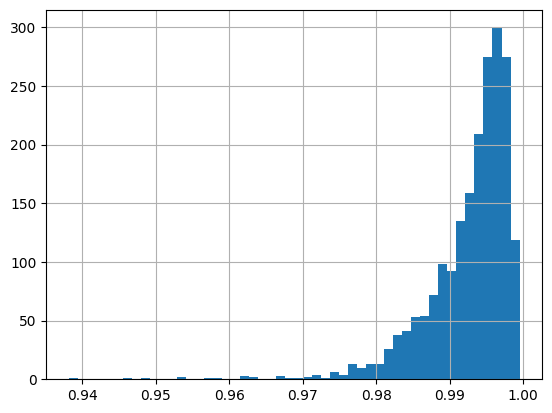

In [5]:
df["rule_violation"] = pred
df["rule_violation"].hist(bins=50)